## 🏠 Hotel Rating Prediction

Given *TripAdvisor hotel reviews*, let's try to predict the **rating** associated with a given review.

We will use a TensorFlow RNN to make our predictions.

Data source: https://www.kaggle.com/datasets/andrewmvd/trip-advisor-hotel-reviews

### Importing Libraries

In [1]:
import numpy as np
import pandas as pd

import re
from nltk.corpus import stopwords

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.model_selection import train_test_split

import tensorflow as tf

In [2]:
data = pd.read_csv('archive/tripadvisor_hotel_reviews.csv')
data

,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5
...,...,...
20486,"best kept secret 3rd time staying charm, not 5...",5
20487,great location price view hotel great quick pl...,4
20488,"ok just looks nice modern outside, desk staff ...",2
20489,hotel theft ruined vacation hotel opened sept ...,1


In [3]:
data = data.sample(frac=0.25)
data

,Review,Rating
15136,true bargain fantastic end oceania cruise sing...,5
11274,"n't believe bad hype, hi wife spent 5 nights g...",4
2003,"terrible customer service second stay resort, ...",1
14660,great hotel great location let start saying wo...,5
13405,"want live barcelona, boyfriend just returned h...",4
...,...,...
18636,perfect week paradise.. travelled boyfriend ma...,5
8130,"good price good location, pleased level accomm...",4
73,"perfect way, stayed ace seattle short time aug...",5
8394,sabrina concierge tremendous spent week le lit...,5


In [4]:
data.info()

<class 'pandas.DataFrame'>
Index: 5123 entries, 15136 to 19979
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Review  5123 non-null   str  
 1   Rating  5123 non-null   int64
dtypes: int64(1), str(1)
memory usage: 120.1 KB


#### Processing Text

In [5]:
stop_words = stopwords.words('english')

In [6]:
stop_words

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [7]:
def process_text(text):
    text = re.sub(r'\d+', ' ', text)
    text = text.split()
    text = " ".join([word for word in text if word.lower().strip() not in stop_words])
    return text

In [8]:
reviews = data['Review'].apply(process_text)

In [9]:
reviews

15136    true bargain fantastic end oceania cruise sing...
11274    n't believe bad hype, hi wife spent nights gra...
2003     terrible customer service second stay resort, ...
14660    great hotel great location let start saying wo...
13405    want live barcelona, boyfriend returned hotel ...
                               ...                        
18636    perfect week paradise.. travelled boyfriend ma...
8130     good price good location, pleased level accomm...
73       perfect way, stayed ace seattle short time aug...
8394     sabrina concierge tremendous spent week le lit...
19979    easy bali villas outstanding job, asia times s...
Name: Review, Length: 5123, dtype: str

In [10]:
num_words = 2000
tokenizer = Tokenizer(num_words=num_words)

tokenizer.fit_on_texts(reviews)

In [11]:
sequences = tokenizer.texts_to_sequences(reviews)

In [12]:
sequences

[[576,
  1139,
  81,
  169,
  556,
  739,
  904,
  913,
  468,
  1326,
  11,
  52,
  577,
  45,
  1,
  708,
  47,
  2,
  88,
  661,
  404,
  40,
  59,
  449,
  47,
  266,
  1063,
  577,
  286,
  16,
  359,
  119,
  345,
  17,
  174,
  940,
  568,
  109,
  1241,
  334,
  1000,
  55,
  78,
  446,
  832,
  914,
  319,
  30,
  958,
  189,
  81,
  2,
  1107,
  291,
  1556,
  886,
  1376,
  190,
  291,
  1449,
  269,
  1688],
 [4,
  424,
  100,
  203,
  226,
  52,
  413,
  479,
  97,
  93,
  26,
  18,
  5,
  19,
  8,
  2,
  230,
  62,
  133,
  511,
  138,
  75,
  703,
  24,
  124,
  1541,
  1959,
  89,
  27,
  1051,
  100,
  62,
  1801,
  75,
  833,
  237,
  796,
  179,
  347,
  540,
  1771,
  753,
  503,
  142,
  273,
  153,
  746,
  142,
  8,
  125,
  73,
  425,
  47,
  24,
  504,
  158,
  280,
  1336,
  399,
  309,
  746,
  24,
  8,
  593,
  815,
  1689,
  175,
  94,
  4,
  20,
  2,
  1140,
  40,
  4,
  1450,
  14,
  291,
  203,
  45,
  22,
  200,
  204,
  1515,
  128,
  46,
  529,
  675,

In [13]:
max_seq_len = np.max(list(map(lambda x: len(x), sequences)))
print("Max Sequence Length:", max_seq_len)

Max Sequence Length: 1477


In [14]:
inputs = pad_sequences(sequences, maxlen=max_seq_len, padding='post')

In [15]:
inputs

array([[ 576, 1139,   81, ...,    0,    0,    0],
       [   4,  424,  100, ...,    0,    0,    0],
       [ 483,  539,   13, ...,    0,    0,    0],
       ...,
       [  93,   56,   11, ...,    0,    0,    0],
       [ 266,  226,  101, ...,    0,    0,    0],
       [ 153,  619, 1363, ...,    0,    0,    0]],
      shape=(5123, 1477), dtype=int32)

#### Encoding Labels

In [16]:
data['Rating'].value_counts()

Rating
5    2221
4    1513
3     576
2     434
1     379
Name: count, dtype: int64

In [17]:
labels = data['Rating'].apply(lambda x: 1 if x == 5 else 0)

In [18]:
labels.value_counts()

Rating
0    2902
1    2221
Name: count, dtype: int64

In [19]:
labels = np.array(labels)
labels

array([1, 0, 0, ..., 1, 1, 1], shape=(5123,))

#### Splitting Data

In [20]:
train_inputs, test_inputs, train_labels, test_labels = train_test_split(inputs, labels, train_size=0.7, random_state=100)

### Modeling/Training

D:\miniconda3\envs\tfenv\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


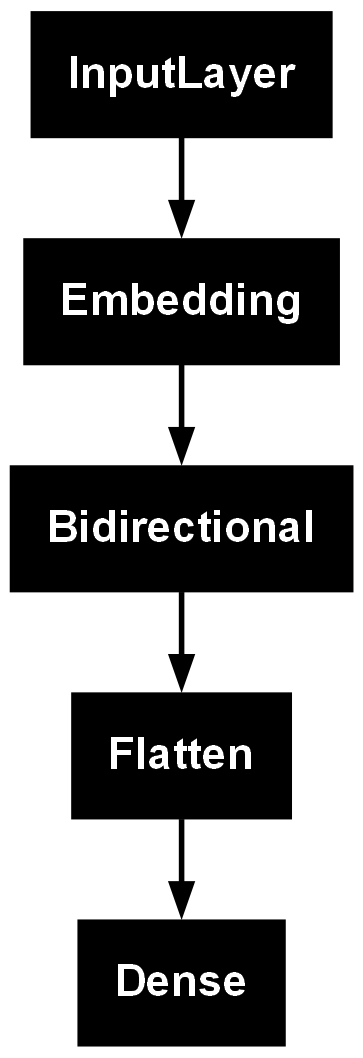

In [21]:
embedding_dim = 32

inputs = tf.keras.Input(shape=(max_seq_len, ))

embedding = tf.keras.layers.Embedding(
    input_dim = num_words,
    output_dim = embedding_dim,
    input_length = max_seq_len
)(inputs)

gru = tf.keras.layers.Bidirectional(tf.keras.layers.GRU(64, return_sequences = True))(embedding)

flatten = tf.keras.layers.Flatten()(gru)

outputs = tf.keras.layers.Dense(1, activation='sigmoid')(flatten)

model = tf.keras.Model(inputs, outputs)

tf.keras.utils.plot_model(model)

In [22]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc')
    ]
)

history = model.fit(
    train_inputs,
    train_labels,
    validation_split=0.2,
    batch_size=32,
    epochs=20,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=2,
            restore_best_weights=True
        )
    ]
)

Epoch 1/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.5736 - auc: 0.5737 - loss: 0.7261 - val_accuracy: 0.7479 - val_auc: 0.8393 - val_loss: 0.5619
Epoch 2/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.8020 - auc: 0.8729 - loss: 0.4467 - val_accuracy: 0.7841 - val_auc: 0.8683 - val_loss: 0.4589
Epoch 3/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.8529 - auc: 0.9309 - loss: 0.3334 - val_accuracy: 0.7744 - val_auc: 0.8536 - val_loss: 0.4941
Epoch 4/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.9132 - auc: 0.9691 - loss: 0.2304 - val_accuracy: 0.7521 - val_auc: 0.8480 - val_loss: 0.5402


### Results

In [23]:
model.evaluate(test_inputs, test_labels)

49/49 ━━━━━━━━━━━━━━━━━━━━ 16s 327ms/step - accuracy: 0.7619 - auc: 0.8552 - loss: 0.4740


[0.4740450084209442, 0.7618737816810608, 0.8552194833755493]